In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("Customer Churn.csv")                #Importing  dataset file
df = pd.DataFrame(data)
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [7]:
df.head()            #Starting 5 rows of the dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges are recoreded &  change datatype of TotalCharges from object to float

In [128]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")        #replace null values in the column TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].astype("float")        #change datatype of TotalCharges from object to float

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
df.isnull().sum()         #Checking the total null values in the dataset

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [24]:
df["customerID"].duplicated().sum()                  #Checking if there is any duplicate values in the unique customer ID

np.int64(0)

In [25]:
def conv(value):
    if value == 1:
        return "yes"
    else :
        return "No"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

converted 0 & 1 values of senior citizen to yes/no tp make it easier to understand

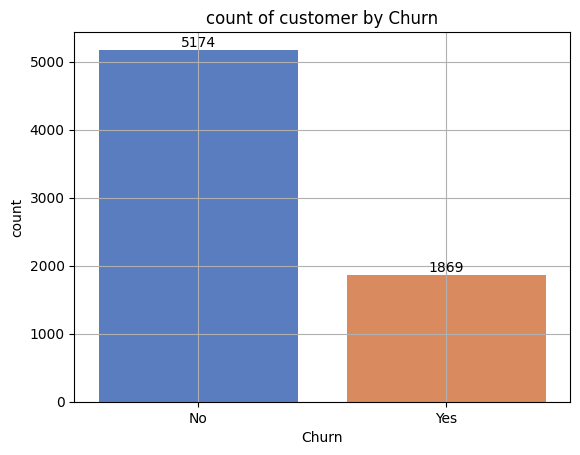

In [61]:
# Create the count plot with color palette 'GnBu'
ax = sns.countplot(x="Churn", data=df, hue="Churn", palette="muted")

# Loop through all containers and add bar labels to each
for container in ax.containers:
    ax.bar_label(container)

plt.title("count of customer by Churn")
# Add a grid to the plot
plt.grid(True)  # Enables the grid

# Display the plot
plt.show()

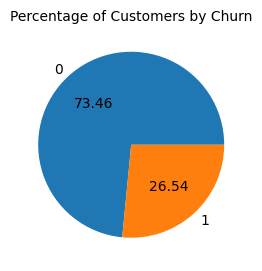

In [129]:
plt.figure(figsize=(3, 4))  # Set the figure size for the plot

# Group by 'Churn' and count occurrences
gb = df.groupby("Churn").agg({"Churn": "count"})

plt.pie(gb["Churn"], labels=gb.index, autopct="%1.2f")  # Create pie chart
plt.title("Percentage of Customers by Churn", fontsize=10)  # Add title to the plot
plt.show()  # Display the plot


#From the given pie chart we can conclude that 26.54% of our customers have churned out. Now lets explore the reason behind it 

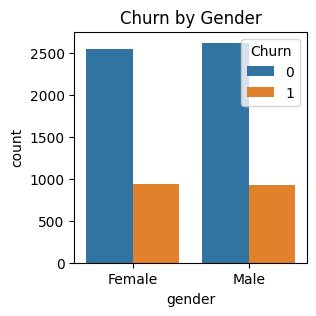

In [130]:
plt.figure(figsize=(3, 3))  # Set the figure size to 3x3 units
sns.countplot(x="gender", data=df, hue="Churn")  # Create a count plot
plt.title("Churn by Gender")  # Add title
plt.show()  # Display the plot

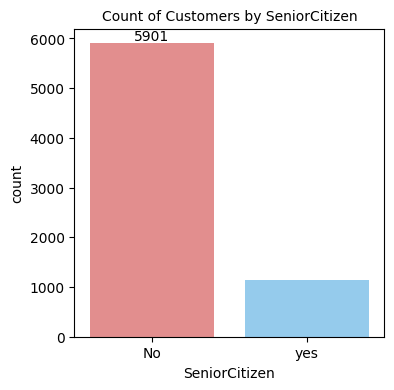

In [131]:
plt.figure(figsize=(4, 4))  # Set the figure size to 4x4 units
ax = sns.countplot(x="SeniorCitizen", data=df, palette=['lightcoral', 'lightskyblue'], hue="SeniorCitizen")  # Create a count plot
ax.bar_label(ax.containers[0])  # Add labels to bars
plt.title("Count of Customers by SeniorCitizen", fontsize=10)  # Add title
plt.show()  # Display the plot

Churn            No   Yes
SeniorCitizen            
No             4508  1393
yes             666   476


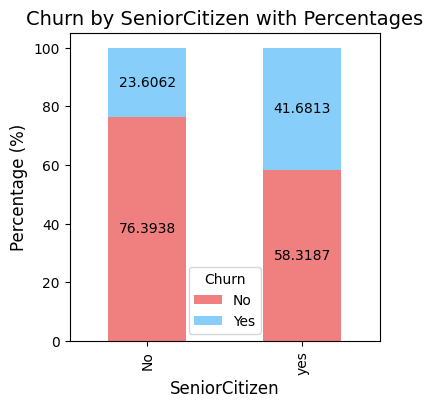

In [75]:
# Step 1: Calculate the percentages for each category within each SeniorCitizen group
# Get the count of each combination of SeniorCitizen and Churn
count_data = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
print(count_data)

# Calculate the percentage for each Churn category within each SeniorCitizen group
percent_data = count_data.div(count_data.sum(axis=1), axis=0) * 100

# Step 2: Plot the stacked bar chart
ax = percent_data.plot(kind='bar', stacked=True, color=['lightcoral', 'lightskyblue'], figsize=(4,4))

# Step 3: Add percentage labels on each segment of the bars
for container in ax.containers:
    # This adds labels to each segment of the stacked bar
    ax.bar_label(container, label_type='center', fontsize=10, color='black')

# Add title and labels
plt.title('Churn by SeniorCitizen with Percentages', fontsize=14)
plt.xlabel('SeniorCitizen', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Show the plot
plt.show()

Higher Churn Rate Among Senior Citizens: Senior citizens have a higher churn rate (41.7%) compared to non-senior citizens (23.6%). This suggests that senior citizens are more likely to churn than non-senior citizens. This could be due to a variety of reasons such as dissatisfaction with the service, technological barriers, or other factors that disproportionately affect older customers.

Loyalty in Non-Senior Citizens: The group with SeniorCitizen = No (likely younger users) shows a stronger tendency to stay with the service, as a much larger percentage (76.4%) did not churn.

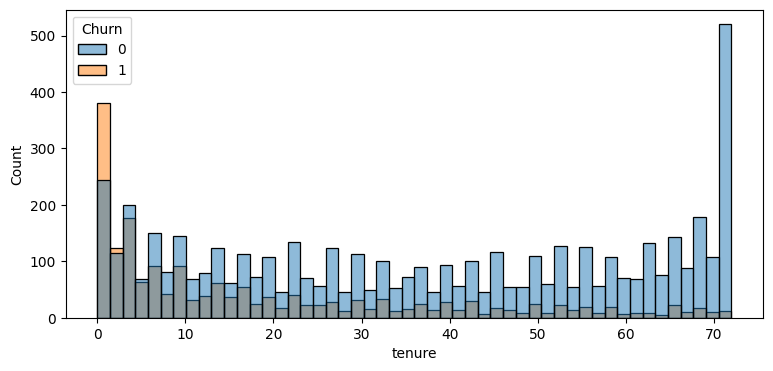

In [132]:
plt.figure(figsize=(9, 4))  # Set the figure size to 9x4 units
sns.histplot(data=df, x="tenure", bins=50, hue="Churn")  # Create a histogram
plt.show()  # Display the plot


People who have used our services for a long time have stayed and people who have used our services for 1 or 2 months have churned

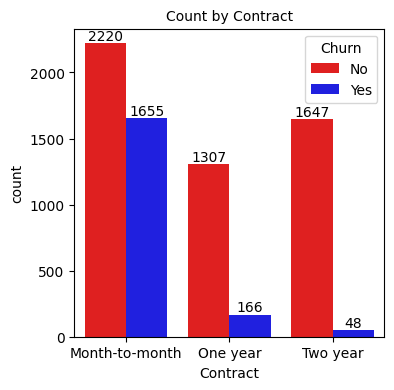

In [110]:
# Create the countplot with custom colors for each category (based on the hue)
plt.figure(figsize=(4, 4))
ax = sns.countplot(x="Contract", data=df, hue="Churn", palette=['red', 'blue'])

# Add the count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

# Add title and display the plot
plt.title("Count by Contract", fontsize=10)
plt.show()

People who have month to month contract are likely to churn from those have one year or two year contract

In [111]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

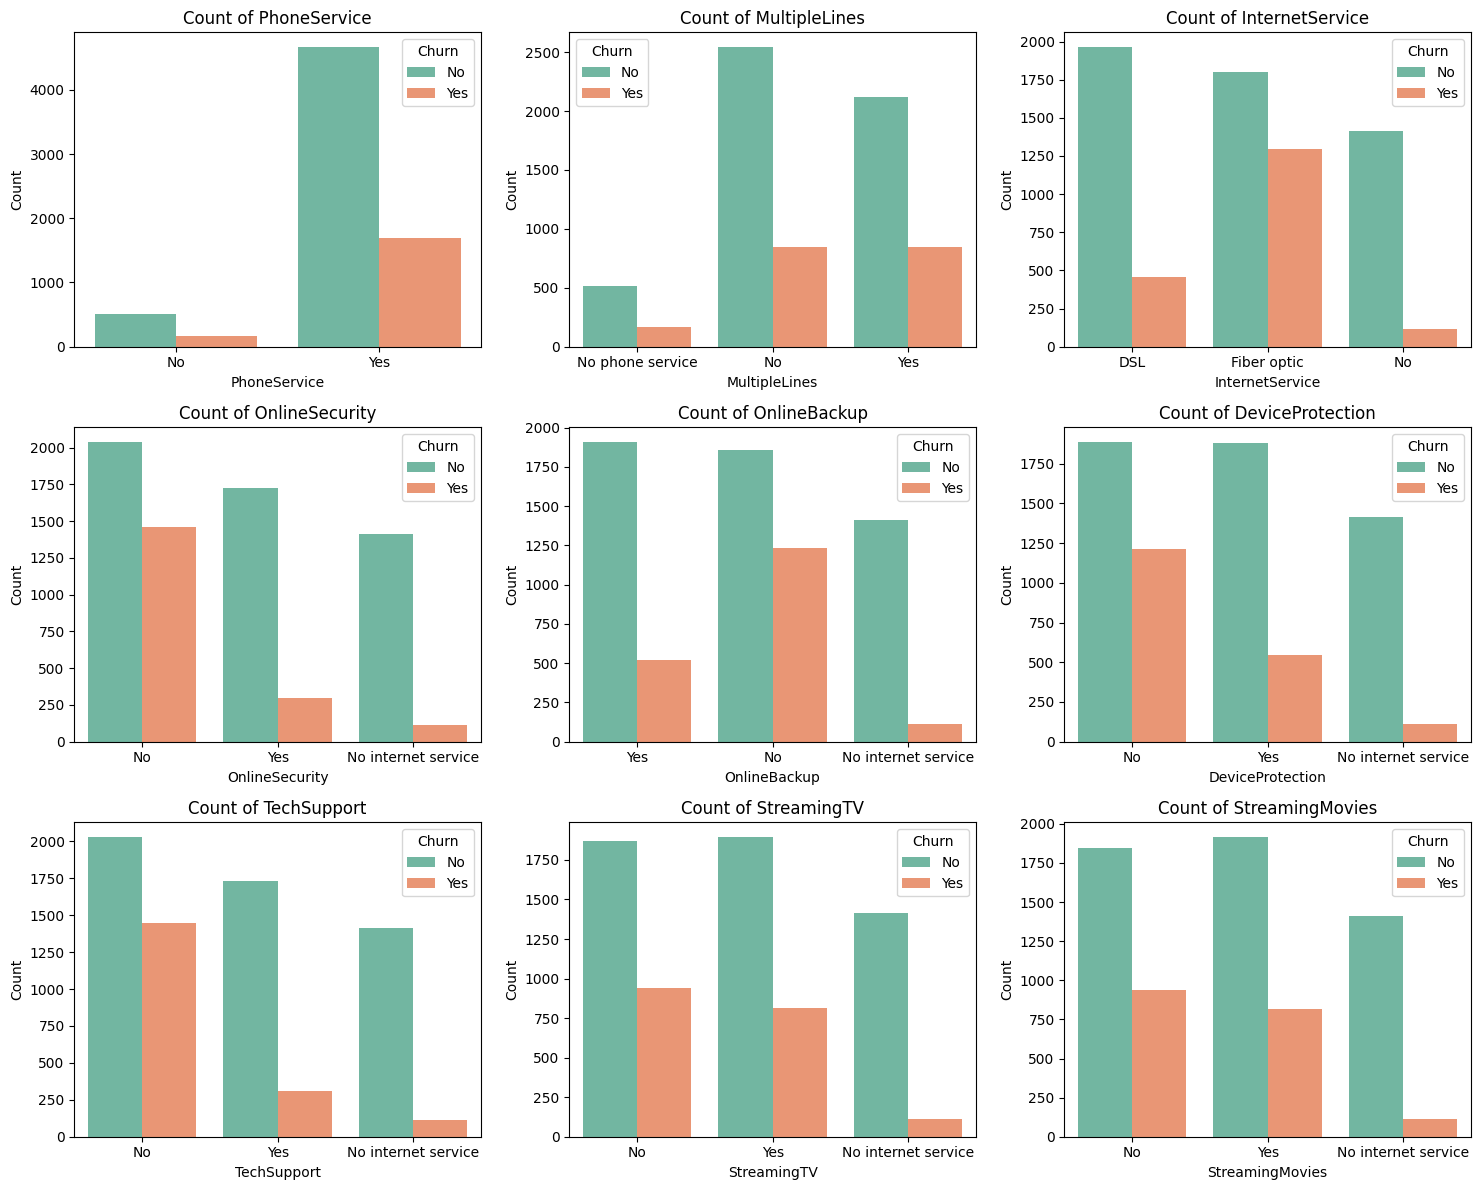

In [117]:
# List of the columns you want to plot
columns = ['PhoneService', 'MultipleLines', 'InternetService', 
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
           'TechSupport', 'StreamingTV', 'StreamingMovies']

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))  # 3x3 grid for 9 plots

# Flatten axes to make it easier to loop through them
axes = axes.flatten()

# Loop through each column and create a countplot
for i, column in enumerate(columns):
    sns.countplot(x=column, data=df, ax=axes[i], hue="Churn",palette="Set2")  # Adjust palette as desired
    axes[i].set_title(f"Count of {column}", fontsize=12)
    axes[i].set_xlabel(column, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()


Customers with fiber optic internet, streaming TV, and streaming movies exhibit higher churn rates, while those with online security, backup, or tech support services tend to churn less. Lack of phone services correlates with lower churn, but having multiple lines increases it. Overall, retention improves with value-added online services but declines with entertainment-based offerings.

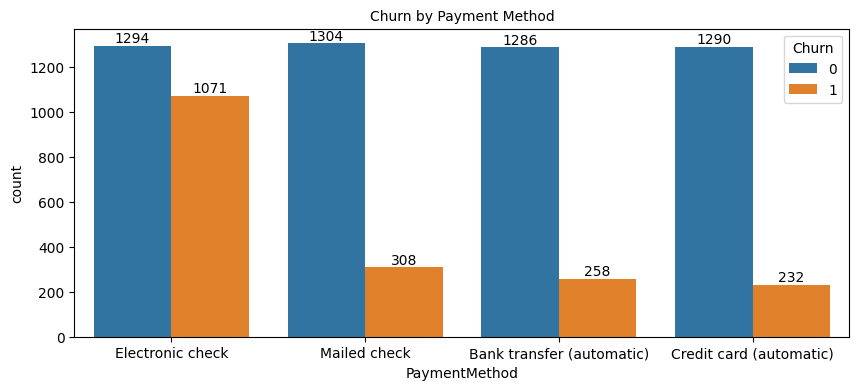

In [133]:
plt.figure(figsize=(10, 4))  # Set the figure size to 10x4 units
ax = sns.countplot(x='PaymentMethod', data=df, hue='Churn')  # Create a count plot
ax.bar_label(ax.containers[0])  # Add labels to bars for the first set
ax.bar_label(ax.containers[1])  # Add labels to bars for the second set
plt.title("Churn by Payment Method", fontsize=10)  # Add title
plt.show()  # Display the plot


###### Customer is likely to churn when he is using electronic check as a payment method